<a href="https://colab.research.google.com/github/Sohum09/Personal-Work/blob/main/chm_aef_unet_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Canopy height regression from AlphaEarth embeddings — NER

AEF (64-ch, 10 m) -> UNet -> **canopy height in metres**. Labels are the Meta/WRI 1 m CHM
(Tolan et al. 2024), streamed anonymously from AWS S3. No Earth Engine account required.

**This is a regression problem, not segmentation.** Everything downstream of the encoder
changes: a 1-channel linear head instead of a softmax, masked Huber instead of CE+Dice,
RMSE/MAE/bias/R2 instead of IoU/F1. The class-prior machinery from the bamboo notebook is gone
— it has no meaning here.

**What the experiment isolates.** Same two AOIs, same embeddings, same spatial-block split as
the bamboo run. Only the target changes. If AEF -> CHM works where AEF -> bamboo did not, the
difference is attributable to label quality rather than to the embeddings or the architecture.

**Honest framing of the target.** The Tolan CHM is itself a model output — a ViT+decoder
prediction from Maxar RGB, not a lidar measurement. Training on it is model distillation. It
saturates in tall canopy and its source imagery dates vary per tile, so agreement with it is
not the same as accuracy against real canopy height. Section 6 quantifies both issues on your
AOIs before you train.

**Attribution (both CC-BY 4.0, both required):**
> AlphaEarth Foundations Satellite Embedding, produced by Google and Google DeepMind.
> High Resolution Canopy Height Maps by Meta and WRI (2024). Source imagery (c) 2016 Maxar.
> Tolan et al. (2024), Remote Sensing of Environment 300, 113888.


## 0. Install & runtime

Runtime -> Change runtime type -> **GPU**.

In [ ]:
!pip -q install aef-loader rasterio geopandas s3fs nest_asyncio
import torch, sys
print("python", sys.version.split()[0], "| torch", torch.__version__,
      "| cuda:", torch.cuda.is_available(),
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

python 3.13.15 | torch 2.11.0+cu128 | cuda: True | Tesla T4


## 1. Configuration

`CHM_PREFIX` selects the label source. v1 is Tolan et al. 2024 (the paper you cited). A **v2**
now exists — DINOv3-based, Vantor imagery — at
`forests/v2/global/dinov3_global_chm_v2_ml3/`. Switching is a one-line change, but re-run the
section 6 QC afterwards: v2 has different saturation behaviour and different acquisition dates.

`CHM_OVERVIEW=True` reads the CHM from its COG overview pyramid instead of full resolution.
Your train AOI is 5.4 **billion** pixels at 1 m; at overview factor 8 that becomes 84 million,
a 64x reduction. The cost is that overviews are already mean-aggregated, so only
`CHM_AGG="mean"` is meaningful with it on. Set it False if you need max or p95 height, and
expect a long download.

In [ ]:
from pathlib import Path
import numpy as np, random, torch

CFG = dict(
    # --- paths -------------------------------------------------------------
    BBOX_DIR = Path("/content/bbox"),        # unzip bbox_shapefiles.zip here
    WORK     = Path("/content/chm_work"),
    TRAIN_BBOX = "training_bbox_v2.cpg.shp", # note the doubled extension
    TEST_BBOX  = "test_bbox.shp",
    # --- AEF ---------------------------------------------------------------
    YEARS    = [2018],
    BUFFER_M = 640,
    # --- CHM labels --------------------------------------------------------
    CHM_BUCKET = "dataforgood-fb-data",
    CHM_PREFIX = "forests/v1/alsgedi_global_v6_float",   # v1, Tolan et al. 2024
    CHM_OVERVIEW = True,      # read from COG overviews: 64x less data
    CHM_AGG      = "mean",    # "mean" (works with overviews) | "max" (needs full res)
    CHM_MAX_VALID = 120.0,    # metres; anything above is a defect, not a tree
    # --- target ------------------------------------------------------------
    LOG_TARGET = False,       # train on log1p(height) instead of metres
    HUBER_DELTA = 2.0,        # metres; below this the loss is quadratic
    # --- loss / under-prediction -------------------------------------------
    # "huber" predicts the conditional MEAN. With a zero-inflated, right-skewed
    # target the mean is dragged down by the zero mass, which under-predicts
    # every forested pixel. "pinball" predicts conditional QUANTILES instead.
    # All TAUS are trained jointly from one shared trunk, so the whole
    # bias/RMSE curve comes out of a single run and tau is chosen on validation.
    LOSS = "pinball",
    TAUS = [0.50, 0.60, 0.65, 0.70, 0.80],
    TAU_SELECT_SCOPE = "forest",   # "forest" (>= MIN_HEIGHT) or "all"
    # --- evaluation scope ---------------------------------------------------
    MIN_HEIGHT = 2.0,         # metres; the "is this canopy at all" threshold
    TRAIN_ON_FOREST_ONLY = False,  # mask <MIN_HEIGHT out of TRAINING too
    # --- inference ----------------------------------------------------------
    TTA = True,               # 8-fold dihedral test-time augmentation
    # --- patches -----------------------------------------------------------
    PATCH = 128, STRIDE = 64,
    MIN_VALID_FRAC = 0.50,    # patches need real CHM to be worth a gradient step
    VAL_BLOCK_PX = 512, VAL_FRACTION = 0.20,
    # --- training ----------------------------------------------------------
    # An "epoch" is STEPS_PER_EPOCH random draws, NOT a full pass over the patch
    # grid. At 10 m the grid holds ~12,900 patches vs ~420 HLS chips at 30 m, so
    # a full pass is 30x Prithvi's and buys little: stride 64 with patch 128
    # means every pixel is already seen 4x per pass.
    BATCH = 32, STEPS_PER_EPOCH = 200, EPOCHS = 40,
    VAL_BATCHES = 40,         # subsample validation too; it is an early-stop signal
    LR = 3e-4, WEIGHT_DECAY = 1e-4,
    BASE_CH = 48, SEED = 42,
    # "cuda" keeps the whole int8 cube in GPU memory (3.46 GB for 64 ch) and
    # removes the data loader entirely. "cpu" pins it in host RAM. "memmap" is
    # the slow fallback. See section 7b.
    CACHE = "auto",
    # --- inference ---------------------------------------------------------
    INFER_PATCH = 256, INFER_STRIDE = 128,
)
CFG["WORK"].mkdir(parents=True, exist_ok=True)
random.seed(CFG["SEED"]); np.random.seed(CFG["SEED"]); torch.manual_seed(CFG["SEED"])
DEV = "cuda" if torch.cuda.is_available() else "cpu"
NODATA = np.float32(np.nan)
print("device:", DEV)

device: cuda


## 2. Read the AOI bounding boxes

In [ ]:
import geopandas as gpd

BB = {}
for split, fn in (("train", CFG["TRAIN_BBOX"]), ("test", CFG["TEST_BBOX"])):
    p = CFG["BBOX_DIR"] / fn
    assert p.exists(), f"missing {p} — unzip bbox_shapefiles.zip into {CFG['BBOX_DIR']}"
    g = gpd.read_file(p)
    assert len(g) == 1, f"{fn}: expected a single rectangle, got {len(g)}"
    BB[split] = g
    print(f"{split:5s} {g.crs}  {[round(v,4) for v in g.total_bounds]}")

# Work in UTM: both AOIs are in zone 46N, matching the AEF tile grid.
UTM = 32646
AOI = {k: v.to_crs(UTM) for k, v in BB.items()}
BOX = {}
for k, g in AOI.items():
    x0, y0, x1, y1 = g.total_bounds
    b = CFG["BUFFER_M"]
    BOX[k] = (x0 - b, y0 - b, x1 + b, y1 + b)
    print(f"{k:5s} UTM46N {(x1-x0)/1000:5.1f} x {(y1-y0)/1000:5.1f} km  "
          f"= {(x1-x0)*(y1-y0)/1e4:,.0f} ha")

# WGS84 bounds are what the CHM tile index is in
LL = {k: tuple(v.total_bounds) for k, v in BB.items()}

train EPSG:4326  [np.float64(90.0293), np.float64(25.2435), np.float64(90.7756), np.float64(25.8952)]
test  EPSG:4326  [np.float64(92.1756), np.float64(25.6385), np.float64(92.8326), np.float64(25.9597)]
train UTM46N  76.4 x  73.7 km  = 563,056 ha
test  UTM46N  66.0 x  35.8 km  = 236,423 ha


## 3. Fetch AEF embeddings

Identical to the bamboo notebook, including the direction-agnostic coordinate slicing: AEF
cubes are not guaranteed north-up, and a fixed descending slice silently selects zero pixels
against an ascending y axis.

In [ ]:
import asyncio, nest_asyncio, json
nest_asyncio.apply()
from aef_loader import AEFIndex, VirtualTiffReader, DataSource

async def fetch_zone(bbox_utm, years, epsg):
    index = AEFIndex(source=DataSource.SOURCE_COOP)
    await index.download(); index.load()
    tiles = await index.query(bbox=bbox_utm, years=(min(years), max(years)), bbox_crs=epsg)
    got = sorted({t.year for t in tiles})
    print(f"  {len(tiles)} tiles, years {got}, zones {sorted({t.utm_zone for t in tiles if t.utm_zone})}")
    for y in years:
        assert y in got, f"AEF year {y} unavailable"
    async with VirtualTiffReader() as reader:
        tree = await reader.open_tiles_by_zone(tiles)
    assert len(tree.children) == 1, f"AOI spans multiple UTM zones: {list(tree.children)}"
    ds = tree[list(tree.children)[0]].ds
    x0, y0, x1, y1 = bbox_utm

    def dir_slice(coord, lo, hi):
        v = np.asarray(coord)
        return slice(hi, lo) if (v.size > 1 and v[0] > v[-1]) else slice(lo, hi)

    ds = ds.sel(x=dir_slice(ds.x.values, x0, x1), y=dir_slice(ds.y.values, y0, y1))
    assert ds.sizes["x"] and ds.sizes["y"], (
        f"empty AOI selection (x={ds.sizes['x']}, y={ds.sizes['y']}) — check bbox_crs")
    ds = ds.sortby("x").sortby("y", ascending=False)      # force north-up
    ds = ds.sel(time=[t for t in ds.time.values if int(str(t)[:4]) in years])
    print(f"  selected {ds.sizes['y']} x {ds.sizes['x']} px, {ds.sizes['time']} step(s)")
    return ds

In [ ]:
from rasterio.transform import from_origin

def download_aef(split):
    dat  = CFG["WORK"] / f"aef_{split}.dat"
    meta = CFG["WORK"] / f"aef_{split}.json"
    if dat.exists() and meta.exists():
        print(f"{split}: cached"); return json.loads(meta.read_text())
    print(f"{split}: querying AEF index…")
    ds = asyncio.run(fetch_zone(BOX[split], CFG["YEARS"], UTM))
    emb = ds["embeddings"]
    nt, nb, H, W = (emb.sizes[d] for d in ("time", "band", "y", "x"))
    C = nt * nb
    xs, ys = ds.x.values, ds.y.values
    assert ys[0] > ys[-1] and xs[0] < xs[-1], "grid is not north-up / west-east"
    res = float(abs(xs[1] - xs[0]))
    tr = from_origin(xs[0] - res/2, ys[0] + res/2, res, res)
    print(f"{split}: {H} x {W} px, {C} ch, {C*H*W/1e9:.2f} GB int8")
    mm = np.lib.format.open_memmap(dat, mode="w+", dtype=np.int8, shape=(C, H, W))
    for y0 in range(0, H, 1024):
        y1 = min(y0 + 1024, H)
        mm[:, y0:y1, :] = emb.isel(y=slice(y0, y1)).values.reshape(C, y1-y0, W)
        print(f"  rows {y0:6d}/{H}", end="\r")
    mm.flush(); del mm
    m = dict(shape=[C, H, W], res=res, epsg=UTM, transform=list(tr)[:6],
             bounds=[float(v) for v in BOX[split]], years=CFG["YEARS"])
    meta.write_text(json.dumps(m, indent=2))
    print(f"\n{split}: -> {dat}")
    return m

META = {s: download_aef(s) for s in ("train", "test")}

train: cached
test: cached


## 4. Fetch the CHM and resample onto the AEF grid

The CHM is 1 m; AEF is 10 m. Rather than downloading 5.4 billion pixels and averaging, we open
each COG at the overview level whose resolution is still finer than 10 m (factor 8 -> 8 m) and
average-resample that onto the exact AEF grid. Reads 1.56% of the full-resolution data.

Reprojection is per-tile into the destination window, so CRS differences between CHM tiles and
UTM 46N are handled by `rasterio.warp.reproject` rather than assumed away.

In [ ]:
import s3fs, rasterio, warnings
from rasterio.warp import reproject, Resampling, transform_bounds
from rasterio.windows import from_bounds as win_from_bounds, transform as win_transform
from rasterio.transform import Affine

fs = s3fs.S3FileSystem(anon=True)      # public bucket, no AWS account
root = f"{CFG['CHM_BUCKET']}/{CFG['CHM_PREFIX']}"

idx_local = CFG["WORK"] / "chm_tiles.geojson"
if not idx_local.exists():
    fs.get(f"{root}/tiles.geojson", str(idx_local))
TILES = gpd.read_file(idx_local)
print(f"{len(TILES)} CHM tiles globally | columns: {list(TILES.columns)}")

id_col = next((c for c in ("tile", "tile_id", "quadkey", "name", "id")
               if c in TILES.columns), None)
assert id_col, f"no recognisable tile-id column in {list(TILES.columns)}"
print(f"using tile-id column: '{id_col}'  e.g. {TILES[id_col].iloc[0]!r}")

def tiles_for(split):
    from shapely.geometry import box
    sel = TILES[TILES.intersects(box(*LL[split]))]
    return sel[id_col].tolist()

for s in ("train", "test"):
    t = tiles_for(s)
    print(f"{s:5s}: {len(t)} intersecting CHM tiles -> {t[:6]}{'…' if len(t)>6 else ''}")

56145 CHM tiles globally | columns: ['tile', 'geometry']
using tile-id column: 'tile'  e.g. '023013213'
train: 4 intersecting CHM tiles -> ['132022003', '132022021', '132022002', '132022020']
test : 4 intersecting CHM tiles -> ['132022102', '132022120', '132022031', '132022013']


In [ ]:
def pick_overview(src, target_res):
    """Largest decimation still finer than the target grid, else full res."""
    if not CFG["CHM_OVERVIEW"]:
        return None
    ovs = src.overviews(1)
    src_res = abs(src.transform.a)
    ok = [i for i, f in enumerate(ovs) if src_res * f <= target_res]
    return max(ok) if ok else None

def build_chm(split):
    out = CFG["WORK"] / f"chm_{split}.npy"
    if out.exists():
        print(f"{split}: cached"); return np.load(out, mmap_mode="r")

    meta = META[split]; C, H, W = meta["shape"]
    dst_tr = Affine(*meta["transform"]); dst_crs = f"EPSG:{meta['epsg']}"
    res = meta["res"]
    dst = np.full((H, W), np.nan, np.float32)
    resamp = Resampling.average if CFG["CHM_AGG"] == "mean" else Resampling.max
    if CFG["CHM_AGG"] == "max" and CFG["CHM_OVERVIEW"]:
        warnings.warn("CHM_AGG='max' with overviews on: overviews are pre-averaged, "
                      "so this is NOT true max height. Set CHM_OVERVIEW=False.")

    ids = tiles_for(split)
    env = dict(AWS_NO_SIGN_REQUEST="YES", GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR",
               GDAL_HTTP_MAX_RETRY="5", GDAL_HTTP_RETRY_DELAY="2")
    with rasterio.Env(**env):
        for n, tid in enumerate(ids, 1):
            uri = f"s3://{root}/chm/{tid}.tif"
            try:
                with rasterio.open(uri) as probe:
                    ov = pick_overview(probe, res)
                    ovs, sres = probe.overviews(1), abs(probe.transform.a)
                src = rasterio.open(uri, overview_level=ov) if ov is not None \
                      else rasterio.open(uri)
            except Exception as e:
                print(f"  [{n}/{len(ids)}] {tid}: SKIP ({type(e).__name__}: {e})")
                continue
            with src:
                fac = ovs[ov] if ov is not None else 1
                tb = transform_bounds(src.crs, dst_crs, *src.bounds)
                win = win_from_bounds(*tb, transform=dst_tr).round_offsets().round_lengths()
                r0, c0 = max(0, int(win.row_off)), max(0, int(win.col_off))
                r1 = min(H, int(win.row_off + win.height))
                c1 = min(W, int(win.col_off + win.width))
                if r1 <= r0 or c1 <= c0:
                    print(f"  [{n}/{len(ids)}] {tid}: outside AOI"); continue
                sub = np.full((r1-r0, c1-c0), np.nan, np.float32)
                reproject(
                    source=rasterio.band(src, 1), destination=sub,
                    src_transform=src.transform, src_crs=src.crs,
                    dst_transform=dst_tr * Affine.translation(c0, r0),
                    dst_crs=dst_crs, resampling=resamp,
                    src_nodata=src.nodata, dst_nodata=np.nan,
                    num_threads=4,
                )
                ok = np.isfinite(sub)
                dst[r0:r1, c0:c1][ok] = sub[ok]
                print(f"  [{n}/{len(ids)}] {tid}: src {sres*fac:.0f} m (ovr {fac}x), "
                      f"{ok.sum():,} px placed")

    bad = (dst < 0) | (dst > CFG["CHM_MAX_VALID"])
    dst[bad] = np.nan
    cov = np.isfinite(dst).mean()
    print(f"{split}: CHM coverage {100*cov:.2f}% of the AEF grid, "
          f"{int(bad.sum()):,} px rejected as out-of-range")
    np.save(out, dst)
    return np.load(out, mmap_mode="r")

CHM = {s: build_chm(s) for s in ("train", "test")}

train: cached
test: cached


## 5. Validity mask

A pixel is trainable only if the CHM is finite **and** the AEF embedding exists. AEF marks
missing data with `-128` across all 64 channels; those pixels carry no information regardless
of how good the label is.

In [ ]:
def valid_mask(split):
    p = CFG["WORK"] / f"valid_{split}.npy"
    if p.exists():
        return np.load(p, mmap_mode="r")
    C, H, W = META[split]["shape"]
    mm = np.load(CFG["WORK"] / f"aef_{split}.dat", mmap_mode="r")
    v = np.isfinite(np.asarray(CHM[split]))
    for y0 in range(0, H, 2048):
        y1 = min(y0 + 2048, H)
        v[y0:y1] &= ~(mm[:, y0:y1, :] == -128).all(axis=0)
    np.save(p, v)
    return np.load(p, mmap_mode="r")

VALID = {s: valid_mask(s) for s in ("train", "test")}
if CFG["TRAIN_ON_FOREST_ONLY"]:
    v = np.asarray(VALID["train"]).copy()
    v &= (np.asarray(CHM["train"]) >= CFG["MIN_HEIGHT"])
    VALID["train"] = v
    print(f"TRAIN masked to >= {CFG['MIN_HEIGHT']} m: "
          f"{100*v.mean():.1f}% of the train grid remains")
    print("  NOTE: the model now never sees bare ground, so its predictions there are")
    print("  unconstrained. The output is a conditional-on-forest height map, not a")
    print("  wall-to-wall CHM, and needs a separate forest mask to be used as one.")
for s in ("train", "test"):
    v = np.asarray(VALID[s]); c = np.asarray(CHM[s])
    print(f"{s:5s} grid {v.shape}  CHM finite {100*np.isfinite(c).mean():5.2f}%  "
          f"AEF+CHM valid {100*v.mean():5.2f}%  "
          f"({v.sum()*META[s]['res']**2/1e4:,.0f} ha trainable)")

train grid (7496, 7770)  CHM finite 100.00%  AEF+CHM valid 100.00%  (582,439 ha trainable)
test  grid (3710, 6727)  CHM finite 100.00%  AEF+CHM valid 100.00%  (249,572 ha trainable)


## 6. Label QC — do this before training, not after

Three things to establish. **Saturation:** the Tolan CHM is known to compress tall canopy; if
your AOIs have a hard ceiling the model will learn it and your R2 will look better than the
map deserves. **Distribution shift:** the two AOIs are ~230 km apart, and if their height
distributions differ the test error partly measures that, not model quality. **Acquisition
date:** CHM source imagery is per-tile Maxar, dated 2009–2020, while your AEF layer is calendar
2018 — any tile far from 2018 is comparing different years.

,train,test
n,5.824392e+07,2.495717e+07
mean,7.100000e+00,5.996000e+00
std,6.684000e+00,6.310000e+00
p1,0.000000e+00,0.000000e+00
p25,5.510000e-01,8.000000e-02
p50,5.814000e+00,3.963000e+00
p75,1.188800e+01,1.057800e+01
p90,1.677300e+01,1.538600e+01
p95,1.952600e+01,1.799000e+01
p99,2.433300e+01,2.265700e+01


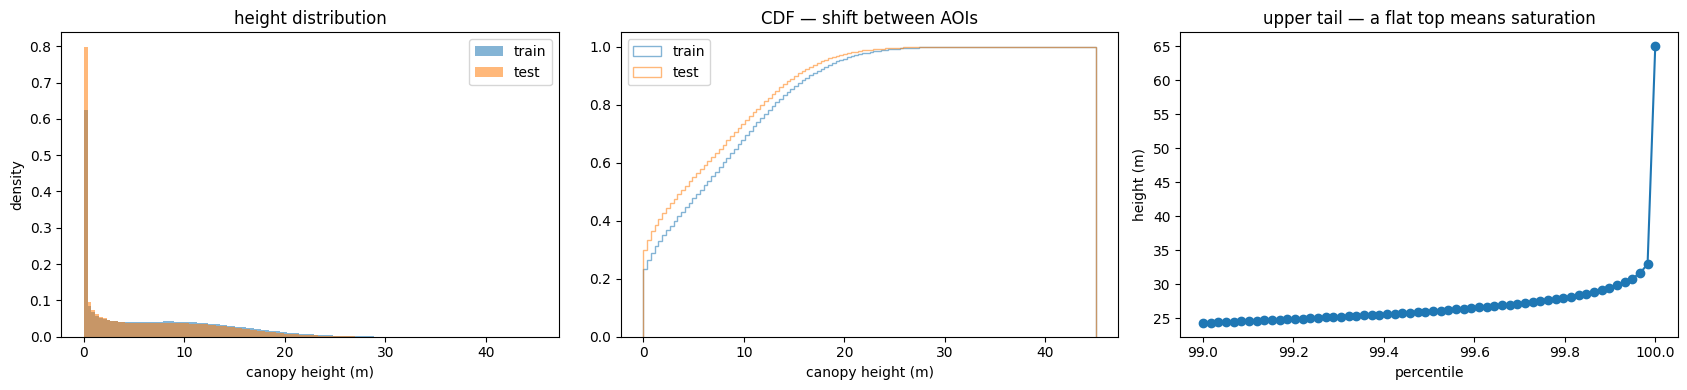

median height shift train -> test: -1.85 m


In [ ]:
import matplotlib.pyplot as plt, pandas as pd

stats = {}
for s in ("train", "test"):
    h = np.asarray(CHM[s])[np.asarray(VALID[s])]
    q = np.percentile(h, [1, 25, 50, 75, 90, 95, 99, 99.9])
    stats[s] = dict(n=len(h), mean=h.mean(), std=h.std(),
                    **{f"p{p}": v for p, v in zip([1,25,50,75,90,95,99,99.9], q)},
                    frac_zero=float((h < 0.5).mean()), max=float(h.max()))
display(pd.DataFrame(stats).round(3))

f, ax = plt.subplots(1, 3, figsize=(17, 4))
for s, c in (("train", "tab:blue"), ("test", "tab:orange")):
    h = np.asarray(CHM[s])[np.asarray(VALID[s])]
    sub = h[np.random.RandomState(0).choice(len(h), min(2_000_000, len(h)), replace=False)]
    ax[0].hist(sub, bins=120, range=(0, 45), density=True, alpha=.55, label=s, color=c)
    ax[1].hist(sub, bins=120, range=(0, 45), density=True, alpha=.55, label=s,
               color=c, cumulative=True, histtype="step", lw=2)
ax[0].set_xlabel("canopy height (m)"); ax[0].set_ylabel("density"); ax[0].legend()
ax[0].set_title("height distribution")
ax[1].set_xlabel("canopy height (m)"); ax[1].set_title("CDF — shift between AOIs"); ax[1].legend()

h = np.asarray(CHM["train"])[np.asarray(VALID["train"])]
top = np.percentile(h, np.linspace(99, 100, 60))
ax[2].plot(np.linspace(99, 100, 60), top, "o-")
ax[2].set_xlabel("percentile"); ax[2].set_ylabel("height (m)")
ax[2].set_title("upper tail — a flat top means saturation")
plt.tight_layout(); plt.show()

d = stats["test"]["p50"] - stats["train"]["p50"]
print(f"median height shift train -> test: {d:+.2f} m")
if abs(d) > 2:
    print("  ! substantial shift; some of the test error will be distribution, not model.")

In [ ]:
# Per-tile acquisition dates, if the bucket exposes them.
try:
    cand = [f for f in fs.ls(root) if f.endswith(".geojson") and "tiles" not in f]
    print("date-bearing index candidates:", cand[:5])
    if cand:
        loc = CFG["WORK"] / "chm_dates.geojson"
        if not loc.exists(): fs.get(cand[0], str(loc))
        DT = gpd.read_file(loc)
        dcol = next((c for c in DT.columns if "date" in c.lower() or "time" in c.lower()), None)
        print("columns:", list(DT.columns), "| date column:", dcol)
        if dcol:
            for s in ("train", "test"):
                ids = set(tiles_for(s))
                sub = DT[DT[id_col].isin(ids)] if id_col in DT.columns else DT
                print(f"  {s}: {sorted(pd.to_datetime(sub[dcol], errors='coerce').dt.year.dropna().unique().astype(int))}")
except Exception as e:
    print(f"date metadata unavailable ({type(e).__name__}) — skipping.")
    print("AEF is calendar 2018; CHM source imagery is 2009-2020, so some")
    print("temporal mismatch is likely. Note it as a limitation.")

date-bearing index candidates: []


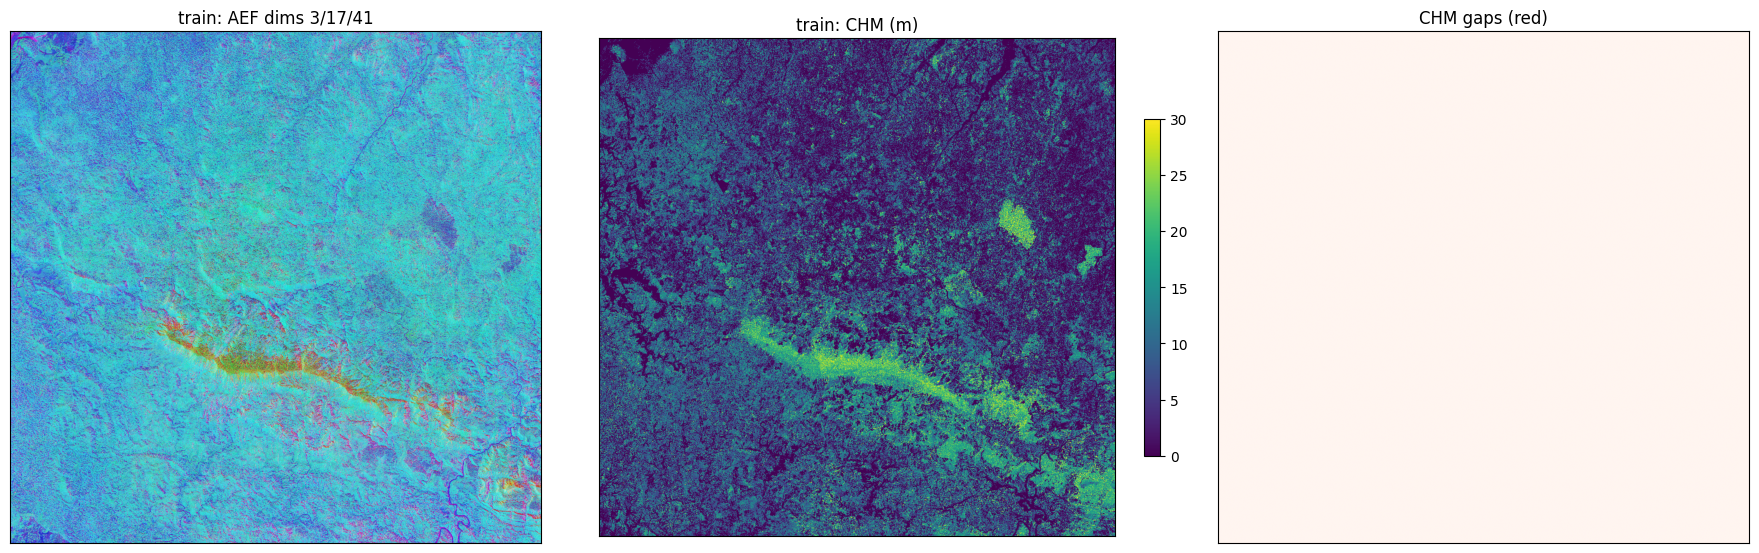

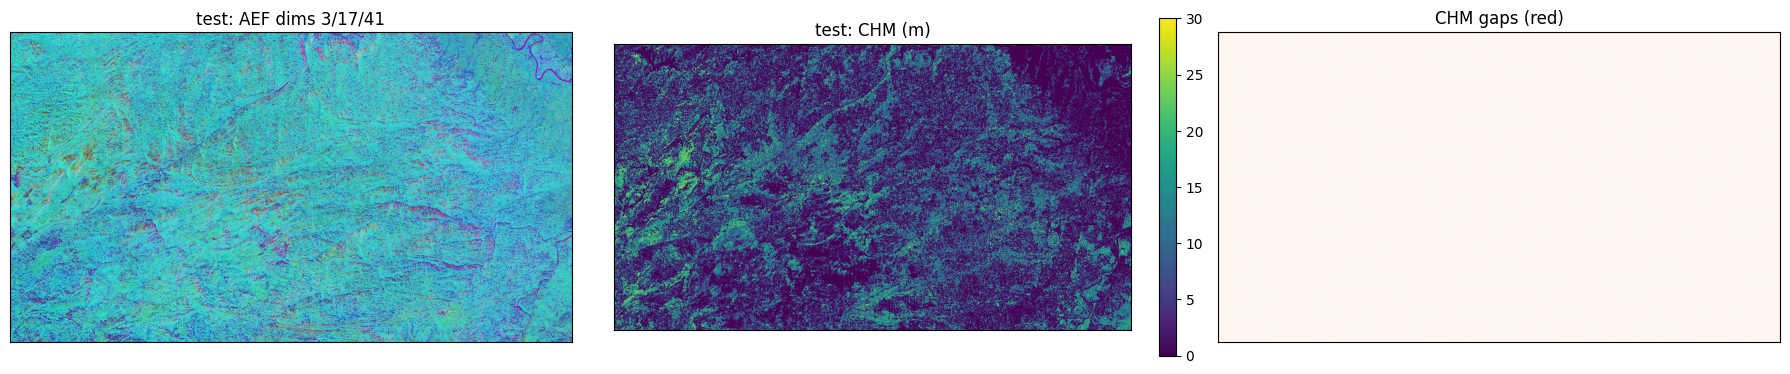

In [ ]:
# Visual alignment check: CHM must line up with the embeddings, not be flipped.
def preview(split, d=8):
    mm = np.load(CFG["WORK"] / f"aef_{split}.dat", mmap_mode="r")
    rgb = np.stack([mm[i, ::d, ::d].astype(np.float32) for i in (3, 17, 41)], -1)
    rgb = (rgb - rgb.min()) / (np.ptp(rgb) + 1e-6)
    chm = np.asarray(CHM[split])[::d, ::d]
    f, ax = plt.subplots(1, 3, figsize=(18, 5.5))
    ax[0].imshow(rgb); ax[0].set_title(f"{split}: AEF dims 3/17/41")
    im = ax[1].imshow(chm, vmin=0, vmax=30, cmap="viridis")
    ax[1].set_title(f"{split}: CHM (m)"); plt.colorbar(im, ax=ax[1], fraction=.03)
    ax[2].imshow(~np.isfinite(chm), cmap="Reds"); ax[2].set_title("CHM gaps (red)")
    for a in ax: a.set_xticks([]); a.set_yticks([])
    plt.tight_layout(); plt.show()

preview("train"); preview("test")

## 7. Patches and spatial-block validation

Same block-holdout logic as the bamboo notebook: 5.12 km blocks, and a patch is discarded
unless all four corners fall in the same split. A random patch split leaks badly here —
neighbouring patches share pixels, and canopy height is strongly spatially autocorrelated, so
random-split validation would be far too optimistic.

In [ ]:
def build_index(split, patch, stride):
    v = np.asarray(VALID[split])
    H, W = v.shape
    ii = np.pad(v.cumsum(0).cumsum(1), ((1,0),(1,0))).astype(np.int64)
    def win(y, x, p): return ii[y+p,x+p] - ii[y,x+p] - ii[y+p,x] + ii[y,x]
    need = CFG["MIN_VALID_FRAC"] * patch * patch
    rows = [(y, x, int(win(y, x, patch)))
            for y in range(0, H-patch+1, stride)
            for x in range(0, W-patch+1, stride)
            if win(y, x, patch) >= need]
    return np.array(rows, dtype=np.int64)

PATCHES = build_index("train", CFG["PATCH"], CFG["STRIDE"])
print(f"{len(PATCHES)} train patches with >= {CFG['MIN_VALID_FRAC']:.0%} valid pixels")

rng = np.random.RandomState(CFG["SEED"])
B = CFG["VAL_BLOCK_PX"]
H, W = np.asarray(VALID["train"]).shape
blocks = rng.rand(int(np.ceil(H/B)), int(np.ceil(W/B))) < CFG["VAL_FRACTION"]

def which(y, x, p):
    c = {blocks[yy//B, xx//B] for yy in (y, y+p-1) for xx in (x, x+p-1)}
    return None if len(c) != 1 else ("val" if c.pop() else "train")

sp = np.array([which(y, x, CFG["PATCH"]) for y, x, _ in PATCHES], dtype=object)
TR_IDX, VA_IDX = np.where(sp == "train")[0], np.where(sp == "val")[0]
print(f"train {len(TR_IDX)} | val {len(VA_IDX)} | dropped at block seams {(sp == None).sum()}")
assert len(VA_IDX), "no validation patches"

13920 train patches with >= 50% valid pixels
train 10201 | val 2583 | dropped at block seams 1136


## 7b. Resident cache — the reason this trains in minutes, not hours

The first version of this notebook streamed patches from a `(C, H, W)` memmap and took ~30 min
per epoch. The cause was layout, not compute: a 128x128 window in that layout is 8,192
discontiguous 128-byte runs, which at 4 KiB pages is **64x read amplification** — about 1 GB of
page traffic per batch to deliver 1 MB of data.

The 64-channel train cube is 3.46 GB of int8. A T4 has 16 GB. So it simply lives on the GPU:
no data loader, no page faults, no host-to-device copies, and dequantization happens on-device
in fp16. Measured GPU cost for this UNet is ~130-260 ms/step at batch 32, so 200 steps is
well under a minute.

In [ ]:
# Defined here because everything below depends on them.
C_IN = META["train"]["shape"][0]        # 64 per AEF year
print("input channels:", C_IN)

def to_target(h):
    """Metres -> training target. log1p spreads the short-vegetation range."""
    return np.log1p(np.clip(h, 0, None)) if CFG["LOG_TARGET"] else h

def from_target(t):
    """Training target -> metres. Every reported metric goes through this."""
    return np.expm1(t) if CFG["LOG_TARGET"] else t

_probe = np.array([0.0, 1.5, 12.0, 38.0], np.float32)
assert np.allclose(from_target(to_target(_probe)), _probe, atol=1e-4),     "target round-trip is lossy"
print(f"target space: {'log1p(m)' if CFG['LOG_TARGET'] else 'metres'} (round-trip verified)")

input channels: 64
target space: metres (round-trip verified)


In [ ]:
def free_gpu_gb():
    if DEV != "cuda": return 0.0
    free, _ = torch.cuda.mem_get_info()
    return free / 1e9

def choose_cache():
    if CFG["CACHE"] != "auto":
        return CFG["CACHE"]
    need = sum(np.prod(META[s]["shape"]) for s in ("train",)) / 1e9
    head = 3.5                                   # model + activations at batch 32
    if DEV == "cuda" and free_gpu_gb() > need + head:
        return "cuda"
    return "cpu"

CACHE = choose_cache()
print(f"cache mode: {CACHE}  (GPU free {free_gpu_gb():.1f} GB)")

CUBE, TGT, MSK = {}, {}, {}
for split in ("train", "test"):
    C, H, W = META[split]["shape"]
    arr = np.load(CFG["WORK"] / f"aef_{split}.dat", mmap_mode="r")
    gb = C*H*W/1e9
    if CACHE == "cuda" and (split == "train" or free_gpu_gb() > gb + 1.5):
        CUBE[split] = torch.from_numpy(np.ascontiguousarray(arr)).to(DEV)
        where = "gpu"
    elif CACHE in ("cuda", "cpu"):
        CUBE[split] = torch.from_numpy(np.ascontiguousarray(arr))
        where = "cpu-ram"
    else:
        CUBE[split] = arr; where = "memmap"
    h = np.nan_to_num(np.asarray(CHM[split]), nan=0.0).astype(np.float32)
    v = np.asarray(VALID[split])
    dst = DEV if (CACHE == "cuda" and where == "gpu") else "cpu"
    TGT[split] = torch.from_numpy(to_target(h)).to(dst)
    MSK[split] = torch.from_numpy(v.astype(np.uint8)).to(dst)
    print(f"  {split:5s} cube {gb:.2f} GB int8 on {where} | target+mask on {dst}")

if DEV == "cuda":
    print(f"GPU after caching: {free_gpu_gb():.1f} GB free")

cache mode: cuda  (GPU free 11.8 GB)
  train cube 3.73 GB int8 on gpu | target+mask on cuda
  test  cube 1.60 GB int8 on gpu | target+mask on cuda
GPU after caching: 9.8 GB free


### GPU dequantization

`dequantize_aef` applies `((v / 127.5) ** 2) * sign(v)` and maps the `-128` sentinel to NaN.
The device version reproduces that arithmetic exactly and substitutes 0 for the sentinel instead
of NaN — those pixels are excluded by the mask anyway, and a NaN would propagate through the
convolutions before the loss ever saw the mask.

The assertion below checks the device implementation against the library's own function rather
than trusting that the formula was transcribed correctly.

In [ ]:
from aef_loader import dequantize_aef

def deq(v):
    """int8 tensor -> float32, matching aef_loader.dequantize_aef."""
    f = v.to(torch.float32) / 127.5
    out = f * f * torch.sign(f)
    return torch.where(v == -128, torch.zeros_like(out), out)

_probe = np.arange(-128, 128, dtype=np.int8)
_ref = np.nan_to_num(dequantize_aef(_probe).astype(np.float32), nan=0.0)
_got = deq(torch.from_numpy(_probe)).numpy()
_bad = np.abs(_ref - _got).max()
print(f"max |device - aef_loader| over all 256 int8 values: {_bad:.3e}")
assert _bad < 1e-5, "GPU dequantization does not match aef_loader.dequantize_aef"
print("dequantization verified against the library implementation")

max |device - aef_loader| over all 256 int8 values: 0.000e+00
dequantization verified against the library implementation


### Batch sampler

Patches are sliced straight out of the resident cube — no `Dataset`, no workers, no collation.
Augmentation is applied per batch rather than per sample: with 8,000 steps the diversity is
ample, and it keeps the whole thing to a handful of kernel launches.

In [ ]:
P = CFG["PATCH"]

def make_batch(split, rows, augment, device=DEV):
    """rows: (n, 2) array of (y, x) patch origins -> x, target, mask on device."""
    cube, tgt, msk = CUBE[split], TGT[split], MSK[split]
    on_dev = isinstance(cube, torch.Tensor) and cube.is_cuda
    xs, ts, ms = [], [], []
    for y, x in rows:
        y, x = int(y), int(x)
        c = cube[:, y:y+P, x:x+P]
        if not isinstance(c, torch.Tensor):
            c = torch.from_numpy(np.ascontiguousarray(c))
        xs.append(c); ts.append(tgt[y:y+P, x:x+P]); ms.append(msk[y:y+P, x:x+P])
    xb = torch.stack(xs); tb = torch.stack(ts); mb = torch.stack(ms)
    if not on_dev:
        xb = xb.to(device, non_blocking=True)
        tb = tb.to(device, non_blocking=True); mb = mb.to(device, non_blocking=True)
    xb = deq(xb)
    tb = tb.float(); mb = mb.float()
    if augment:
        k = int(torch.randint(0, 4, (1,)))
        if k:
            xb = torch.rot90(xb, k, (2, 3)); tb = torch.rot90(tb, k, (1, 2))
            mb = torch.rot90(mb, k, (1, 2))
        if torch.rand(1).item() < .5:
            xb = xb.flip(3); tb = tb.flip(2); mb = mb.flip(2)
        if torch.rand(1).item() < .5:
            xb = xb.flip(2); tb = tb.flip(1); mb = mb.flip(1)
    return xb.contiguous(), (tb * mb).contiguous(), mb.contiguous()

TR_ROWS = PATCHES[TR_IDX, :2]
VA_ROWS = PATCHES[VA_IDX, :2]
rng_t = np.random.RandomState(CFG["SEED"])

def draw(rows, bs):
    return rows[rng_t.choice(len(rows), bs, replace=False)]

xb, yb, vb = make_batch("train", draw(TR_ROWS, CFG["BATCH"]), True)
print("x", tuple(xb.shape), xb.dtype, "| y", tuple(yb.shape), "| valid", round(float(vb.mean()),3))
print("target range (m):", round(float(from_target(yb[vb>0]).min()),2),
      "->", round(float(from_target(yb[vb>0]).max()),2))
assert torch.isfinite(xb).all() and torch.isfinite(yb).all()

x (32, 64, 128, 128) torch.float32 | y (32, 128, 128) | valid 1.0
target range (m): 0.0 -> 37.81


## 9. UNet with a regression head

Same encoder/decoder as the bamboo model — a 1-channel linear output replaces the softmax. `softplus` keeps predictions non-negative, since a negative canopy height is not a thing.

In [ ]:
import torch.nn as nn, torch.nn.functional as F

def gn(c): return nn.GroupNorm(min(8, c), c)

class Block(nn.Module):
    def __init__(s, ci, co):
        super().__init__()
        s.f = nn.Sequential(
            nn.Conv2d(ci, co, 3, padding=1, bias=False), gn(co), nn.SiLU(True),
            nn.Conv2d(co, co, 3, padding=1, bias=False), gn(co), nn.SiLU(True))
    def forward(s, x): return s.f(x)

class UNetReg(nn.Module):
    def __init__(s, c_in, base=48, depth=4, p_drop=0.1, n_out=1):
        super().__init__()
        chs = [base * 2**i for i in range(depth)]
        s.enc, s.pool = nn.ModuleList(), nn.MaxPool2d(2)
        prev = c_in
        for c in chs: s.enc.append(Block(prev, c)); prev = c
        s.bott = Block(prev, prev*2); s.drop = nn.Dropout2d(p_drop)
        s.up, s.dec = nn.ModuleList(), nn.ModuleList(); prev *= 2
        for c in reversed(chs):
            s.up.append(nn.ConvTranspose2d(prev, c, 2, stride=2))
            s.dec.append(Block(c*2, c)); prev = c
        s.head = nn.Conv2d(prev, n_out, 1)
    def forward(s, x):
        sk = []
        for e in s.enc: x = e(x); sk.append(x); x = s.pool(x)
        x = s.drop(s.bott(x))
        for u, d, k in zip(s.up, s.dec, reversed(sk)):
            x = u(x)
            if x.shape[-2:] != k.shape[-2:]:
                x = F.interpolate(x, size=k.shape[-2:], mode="nearest")
            x = d(torch.cat([x, k], 1))
        out = F.softplus(s.head(x))                 # (B, K, H, W), >= 0
        return out.squeeze(1) if out.shape[1] == 1 else out

N_OUT = len(CFG["TAUS"]) if CFG["LOSS"] == "pinball" else 1
model = UNetReg(C_IN, base=CFG["BASE_CH"], n_out=N_OUT).to(DEV)
print(f"{sum(p.numel() for p in model.parameters())/1e6:.2f} M parameters | "
      f"{N_OUT} output head(s)")
if N_OUT > 1:
    print("heads predict quantiles:", CFG["TAUS"])

17.49 M parameters | 5 output head(s)
heads predict quantiles: [0.5, 0.6, 0.65, 0.7, 0.8]


## 10. Loss — masked pinball (or Huber)

`MaskedHuber` predicts the conditional **mean**. Your target is zero-inflated (41% of test
pixels below 2 m) and right-skewed, so the conditional mean sits between "bare ground" and
"forest" and under-predicts every forested pixel. That is exactly the error signature in your
results: +0.66 m bias in the 0-2 m bin, negative and growing everywhere above.

`MaskedPinball` predicts conditional **quantiles** instead. For quantile tau the loss is
`max(tau*e, (tau-1)*e)` with `e = y - yhat`, which penalises under-prediction `tau/(1-tau)`
times as hard as over-prediction. All of `TAUS` are trained jointly from one shared trunk, so a
single run produces the whole bias/RMSE curve and tau is picked on validation.

Simulated at your zero-fraction and skill level, on forest pixels: bias -3.83 -> -0.65 m and
RMSE 5.32 -> 4.29 m going from the mean head to tau=0.70. Both improve, because an upper
quantile is a better point estimate than the mean for a right-skewed conditional. Magnitudes
will differ on real data — that is what the validation sweep is for.

Both losses mask identically: the residual is multiplied by the validity mask before reduction
and the denominator counts only valid pixels, so an invalid pixel moves neither.

In [ ]:
class MaskedHuber(nn.Module):
    def __init__(s, delta=2.0):
        super().__init__(); s.d = delta
    def forward(s, pred, targ, valid):
        n = valid.sum()
        if n == 0:                                    # fully invalid batch
            return pred.sum() * 0.0, {"n": 0}
        r = (pred - targ) * valid
        a = r.abs()
        q = torch.clamp(a, max=s.d)
        l = (0.5*q**2 + s.d*(a - q))
        loss = (l * valid).sum() / n
        with torch.no_grad():
            mae = (a * valid).sum() / n
            rmse = torch.sqrt(((r**2) * valid).sum() / n)
        return loss, {"mae": float(mae), "rmse": float(rmse), "n": int(n)}

class MaskedPinball(nn.Module):
    """Joint quantile regression. pred: (B, K, H, W) for K taus."""
    def __init__(s, taus):
        super().__init__()
        s.register_buffer("t", torch.tensor(taus, dtype=torch.float32).view(1, -1, 1, 1))
    def forward(s, pred, targ, valid):
        n = valid.sum()
        if n == 0:
            return pred.sum() * 0.0, {"n": 0}
        if pred.dim() == 3: pred = pred.unsqueeze(1)
        y = targ.unsqueeze(1); v = valid.unsqueeze(1)
        e = (y - pred) * v
        l = torch.maximum(s.t * e, (s.t - 1.0) * e)
        loss = (l * v).sum() / (n * pred.shape[1])
        with torch.no_grad():
            k = min(range(pred.shape[1]),
                    key=lambda i: abs(float(s.t[0, i, 0, 0]) - 0.5))
            r = (pred[:, k] - targ) * valid
            mae = (r.abs() * valid).sum() / n
            rmse = torch.sqrt(((r**2) * valid).sum() / n)
        return loss, {"mae": float(mae), "rmse": float(rmse), "n": int(n)}

criterion = (MaskedPinball(CFG["TAUS"]).to(DEV) if CFG["LOSS"] == "pinball"
             else MaskedHuber(CFG["HUBER_DELTA"]))
print(f"loss: {CFG['LOSS']}"
      + (f" over taus {CFG['TAUS']}" if CFG["LOSS"] == "pinball" else ""))

# --- verify invalid pixels are inert ------------------------------------------
_m = UNetReg(C_IN, base=8, n_out=N_OUT).to(DEV)
_x = torch.randn(2, C_IN, 64, 64, device=DEV)
_t = torch.rand(2, 64, 64, device=DEV) * 30
_v = torch.zeros(2, 64, 64, device=DEV); _v[0, :8, :8] = 1.0     # 64 valid px
_t = _t * _v
_l, _s = criterion(_m(_x), _t, _v); _l.backward()
g_part = sum(p.grad.abs().sum().item() for p in _m.parameters() if p.grad is not None)
_m.zero_grad()
_v0 = torch.zeros_like(_v)
_l0, _s0 = criterion(_m(_x), _t*0, _v0); _l0.backward()
g_none = sum(p.grad.abs().sum().item() for p in _m.parameters() if p.grad is not None)
print(f"64 valid px -> loss {float(_l):.4f}, grad {g_part:.4f}  {_s}")
print(f" 0 valid px -> loss {float(_l0):.4f}, grad {g_none:.4f}  {_s0}")
assert g_none == 0.0, "invalid pixels are leaking gradient"
assert np.isfinite(float(_l0)), "all-invalid batch produced a non-finite loss"
print("mask verified: invalid pixels contribute nothing, no NaN on empty batches")
del _m, _x, _t, _v

loss: pinball over taus [0.5, 0.6, 0.65, 0.7, 0.8]
64 valid px -> loss 8.2497, grad 41.3442  {'mae': 12.834095001220703, 'rmse': 15.723470687866211, 'n': 64}
 0 valid px -> loss 0.0000, grad 0.0000  {'n': 0}
mask verified: invalid pixels contribute nothing, no NaN on empty batches


/tmp/ipykernel_1073/3118666809.py:57: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print(f"64 valid px -> loss {float(_l):.4f}, grad {g_part:.4f}  {_s}")


### Speed check before committing

Times 20 real steps and projects the full run. If the projection is not in the tens of minutes,
stop and look at the cache mode above rather than starting a run you will lose to the runtime
limit.

In [ ]:
import time

def bench(n=20):
    opt_ = torch.optim.AdamW(model.parameters(), lr=1e-4)
    sc_ = torch.amp.GradScaler("cuda", enabled=(DEV=="cuda"))
    model.train()
    for i in range(n + 3):                      # 3 warmup steps
        if i == 3 and DEV == "cuda":
            torch.cuda.synchronize(); t0 = time.time()
        xb, yb, vb = make_batch("train", draw(TR_ROWS, CFG["BATCH"]), True)
        opt_.zero_grad(set_to_none=True)
        with torch.autocast("cuda", enabled=(DEV=="cuda")):
            loss, _ = criterion(model(xb), yb, vb)
        sc_.scale(loss).backward(); sc_.step(opt_); sc_.update()
    if DEV == "cuda": torch.cuda.synchronize()
    return (time.time() - t0) / n

ms = bench()
ep_s = ms * CFG["STEPS_PER_EPOCH"]
tot = ep_s * CFG["EPOCHS"] / 60
print(f"{ms*1000:6.1f} ms/step at batch {CFG['BATCH']}")
print(f"{ep_s:6.1f} s/epoch ({CFG['STEPS_PER_EPOCH']} steps) + validation")
print(f"{tot:6.1f} min projected for {CFG['EPOCHS']} epochs")
print(f"px-presentations: {CFG['STEPS_PER_EPOCH']*CFG['EPOCHS']*CFG['BATCH']*P*P/1e9:.1f} G "
      f"(Prithvi run was ~6.3 G)")
if tot > 90:
    print()
    print("! Slower than expected. Check the cache mode printed in 7b -")
    print("  'memmap' means you are back on the slow path.")

 217.1 ms/step at batch 32
  43.4 s/epoch (200 steps) + validation
  28.9 min projected for 40 epochs
px-presentations: 4.2 G (Prithvi run was ~6.3 G)


## 11. Training

Model selection on validation **RMSE in metres**, which is the number you will report.

An epoch here is `STEPS_PER_EPOCH` random draws rather than a full pass. The cosine schedule is
defined over total steps, so epoch count and schedule stay consistent.

ep   1  loss  3.8306  [tau=0.80] val RMSE 10.254 m  MAE  8.536  bias -8.502  R2 -1.9784  [  0.9 min]  <- best
ep   2  loss  3.7606  [tau=0.80] val RMSE  9.961 m  MAE  8.200  bias -8.145  R2 -1.8104  [  1.8 min]  <- best
ep   3  loss  3.5171  [tau=0.80] val RMSE  9.176 m  MAE  7.430  bias -7.247  R2 -1.3853  [  2.8 min]  <- best
ep   4  loss  3.0255  [tau=0.80] val RMSE  7.942 m  MAE  6.200  bias -5.607  R2 -0.7865  [  3.7 min]  <- best
ep   5  loss  2.4591  [tau=0.80] val RMSE  6.722 m  MAE  5.143  bias -3.688  R2 -0.2801  [  4.6 min]  <- best
ep   6  loss  2.0006  [tau=0.80] val RMSE  5.949 m  MAE  4.585  bias -1.993  R2 -0.0025  [  5.5 min]  <- best
ep   7  loss  1.7379  [tau=0.80] val RMSE  5.522 m  MAE  4.320  bias -0.791  R2 0.1363  [  6.5 min]  <- best
ep   8  loss  1.5645  [tau=0.70] val RMSE  5.422 m  MAE  4.223  bias -0.949  R2 0.1674  [  7.4 min]  <- best
ep   9  loss  1.4776  [tau=0.70] val RMSE  5.180 m  MAE  4.038  bias -0.738  R2 0.2399  [  8.3 min]  <- best
ep  10  loss 

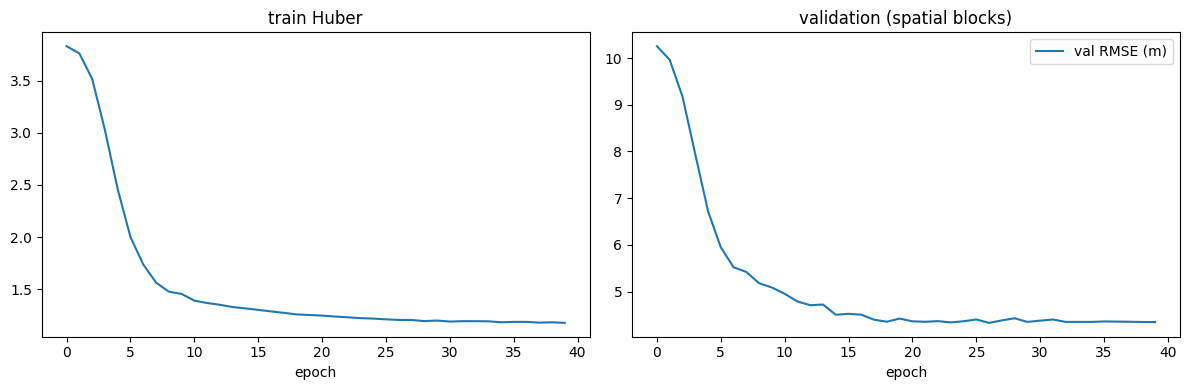

In [ ]:
from collections import defaultdict

def agg_metrics(pred, targ, valid):
    p = from_target(pred); t = from_target(targ)
    v = valid.astype(bool); e = (p - t)[v]
    return dict(n=int(v.sum()), se=float((e**2).sum()), ae=float(np.abs(e).sum()),
                bias=float(e.sum()), ssum=float(t[v].sum()), sq=float((t[v]**2).sum()))

def finish(a):
    n = max(a["n"], 1); mt = a["ssum"]/n
    sstot = a["sq"] - n*mt**2
    return dict(rmse=np.sqrt(a["se"]/n), mae=a["ae"]/n, bias=a["bias"]/n,
                r2=1 - a["se"]/max(sstot, 1e-9), n=a["n"])

@torch.no_grad()
def evaluate(n_batches, scope=None):
    """Metrics for EVERY output head. scope='forest' restricts to >= MIN_HEIGHT."""
    model.eval()
    accs = [defaultdict(float) for _ in range(N_OUT)]
    rs = np.random.RandomState(0)
    nb = min(n_batches, max(1, len(VA_ROWS)//CFG["BATCH"]))
    for _ in range(nb):
        rows = VA_ROWS[rs.choice(len(VA_ROWS), min(CFG["BATCH"], len(VA_ROWS)), replace=False)]
        xb, yb, vb = make_batch("train", rows, False)
        with torch.autocast("cuda", enabled=(DEV=="cuda")):
            pr = model(xb)
        if pr.dim() == 3: pr = pr.unsqueeze(1)
        pr = pr.float().cpu().numpy()
        yn = yb.cpu().numpy(); vn = vb.cpu().numpy().astype(bool)
        if scope == "forest":
            vn = vn & (from_target(yn) >= CFG["MIN_HEIGHT"])
        for k in range(N_OUT):
            for kk, vv in agg_metrics(pr[:, k], yn, vn).items():
                accs[k][kk] += vv
    return [finish(a) for a in accs]


opt = torch.optim.AdamW(model.parameters(), lr=CFG["LR"], weight_decay=CFG["WEIGHT_DECAY"])
TOTAL = CFG["STEPS_PER_EPOCH"] * CFG["EPOCHS"]
sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=CFG["LR"], total_steps=TOTAL,
                                            pct_start=0.15)
scaler = torch.amp.GradScaler("cuda", enabled=(DEV=="cuda"))
ckpt = CFG["WORK"] / "unet_chm_best.pt"
best, hist = np.inf, defaultdict(list)
t_start = time.time()

for ep in range(1, CFG["EPOCHS"]+1):
    model.train(); run = 0.0
    for _ in range(CFG["STEPS_PER_EPOCH"]):
        xb, yb, vb = make_batch("train", draw(TR_ROWS, CFG["BATCH"]), True)
        opt.zero_grad(set_to_none=True)
        with torch.autocast("cuda", enabled=(DEV=="cuda")):
            loss, _ = criterion(model(xb), yb, vb)
        scaler.scale(loss).backward(); scaler.unscale_(opt)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(opt); scaler.update(); sched.step()
        run += float(loss)
    ms = evaluate(CFG["VAL_BATCHES"], scope=CFG["TAU_SELECT_SCOPE"])
    kbest = int(np.argmin([m["rmse"] for m in ms]))   # best head in the chosen scope
    m = ms[kbest]
    hist["loss"].append(run/CFG["STEPS_PER_EPOCH"]); hist["rmse"].append(m["rmse"])
    hist["r2"].append(m["r2"]); hist["kbest"].append(kbest)
    flag = ""
    if m["rmse"] < best:
        best = m["rmse"]; torch.save(model.state_dict(), ckpt); flag = "  <- best"
    el = (time.time()-t_start)/60
    tag = f"tau={CFG['TAUS'][kbest]:.2f}" if N_OUT > 1 else "mean"
    print(f"ep {ep:3d}  loss {run/CFG['STEPS_PER_EPOCH']:7.4f}  [{tag}] "
          f"val RMSE {m['rmse']:6.3f} m  MAE {m['mae']:6.3f}  bias {m['bias']:+6.3f}  "
          f"R2 {m['r2']:6.4f}  [{el:5.1f} min]{flag}")

print()
print(f"best val RMSE {best:.3f} m in {(time.time()-t_start)/60:.1f} min -> {ckpt}")

f, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist["loss"]); ax[0].set_title("train Huber"); ax[0].set_xlabel("epoch")
ax[1].plot(hist["rmse"], label="val RMSE (m)"); ax[1].legend()
ax[1].set_xlabel("epoch"); ax[1].set_title("validation (spatial blocks)")
plt.tight_layout(); plt.show()

### Choose tau on validation

The whole bias/RMSE curve from one run. Selection happens on **held-out spatial blocks in the
train region** — never on the test AOI, which would turn your test score into a validation
score.

,scope,tau,rmse,mae,bias,r2
0,all,0.50,4.0661,2.8873,-0.3320,0.6511
1,all,0.60,4.1295,2.9909,0.5289,0.6401
2,all,0.65,4.2486,3.1121,1.0054,0.6191
3,all,0.70,4.4324,3.2874,1.5054,0.5854
4,all,0.80,5.0686,3.8790,2.7102,0.4578
5,forest,0.50,4.4644,3.4202,-1.1940,0.4222
6,forest,0.60,4.3215,3.3242,-0.2102,0.4586
7,forest,0.65,4.3392,3.3522,0.3234,0.4542
8,forest,0.70,4.4188,3.4352,0.8711,0.4340
9,forest,0.80,4.8603,3.8500,2.1640,0.3152



selected head 1 (tau=0.60) by RMSE in scope 'forest'


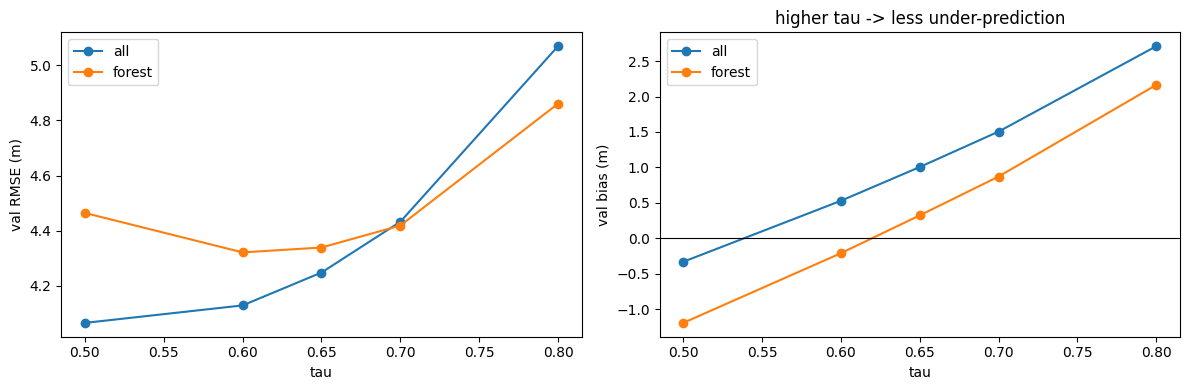

In [ ]:
model.load_state_dict(torch.load(ckpt, map_location=DEV))
rows = []
for scope in ("all", "forest"):
    for k, m in enumerate(evaluate(CFG["VAL_BATCHES"] * 2, scope=None if scope=="all" else scope)):
        rows.append(dict(scope=scope, tau=CFG["TAUS"][k] if N_OUT > 1 else np.nan,
                         rmse=m["rmse"], mae=m["mae"], bias=m["bias"], r2=m["r2"]))
sweep = pd.DataFrame(rows)
display(sweep.round(4))

sc = CFG["TAU_SELECT_SCOPE"]
sub = sweep[sweep.scope == ("forest" if sc == "forest" else "all")].reset_index(drop=True)
K_SEL = int(sub.rmse.idxmin())
TAU_SEL = CFG["TAUS"][K_SEL] if N_OUT > 1 else None
print()
print(f"selected head {K_SEL}" + (f" (tau={TAU_SEL:.2f})" if TAU_SEL else "")
      + f" by RMSE in scope '{sc}'")

if N_OUT > 1:
    f, ax = plt.subplots(1, 2, figsize=(12, 4))
    for scope, c in (("all", "tab:blue"), ("forest", "tab:orange")):
        d = sweep[sweep.scope == scope]
        ax[0].plot(d.tau, d.rmse, "o-", color=c, label=scope)
        ax[1].plot(d.tau, d.bias, "o-", color=c, label=scope)
    ax[0].set_xlabel("tau"); ax[0].set_ylabel("val RMSE (m)"); ax[0].legend()
    ax[1].axhline(0, c="k", lw=.8); ax[1].set_xlabel("tau"); ax[1].set_ylabel("val bias (m)")
    ax[1].legend(); ax[1].set_title("higher tau -> less under-prediction")
    plt.tight_layout(); plt.show()

## 12. Per-pixel baseline

Gradient-boosted trees on the raw 64 dims, no spatial context. If the UNet doesn't clear this on the *test* region, the spatial machinery isn't earning its keep — report both numbers regardless.

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor

def sample_px(split, n=400_000):
    """Gather random labelled pixels from the resident cube.

    Fancy-indexing a (C,H,W) memmap at 400k scattered points hits exactly the
    read-amplification problem described in 7b, so route through the cache.
    """
    v = np.asarray(VALID[split]); h = np.asarray(CHM[split])
    ys, xs = np.nonzero(v)
    sel = np.random.RandomState(CFG["SEED"]).choice(len(ys), min(n, len(ys)), replace=False)
    ys, xs = ys[sel], xs[sel]
    cube = CUBE[split]
    X = np.empty((len(ys), C_IN), np.float32)
    yi = torch.as_tensor(ys, dtype=torch.long); xi = torch.as_tensor(xs, dtype=torch.long)
    if isinstance(cube, torch.Tensor):
        if cube.is_cuda: yi, xi = yi.to(DEV), xi.to(DEV)
        for i in range(0, len(ys), 50_000):
            j = slice(i, min(i+50_000, len(ys)))
            X[j] = deq(cube[:, yi[j], xi[j]].T).float().cpu().numpy()
    else:
        for i in range(0, len(ys), 20_000):
            j = slice(i, min(i+20_000, len(ys)))
            X[j] = dequantize_aef(cube[:, ys[j], xs[j]].T.copy()).astype(np.float32)
    return np.nan_to_num(X), h[ys, xs].astype(np.float32)

Xtr, ytr = sample_px("train"); Xte, yte = sample_px("test")
gb = HistGradientBoostingRegressor(max_iter=400, learning_rate=0.08,
                                   loss="absolute_error", random_state=CFG["SEED"])
gb.fit(Xtr, ytr)
pg = gb.predict(Xte)
m_gb = finish(agg_metrics(to_target(pg), to_target(yte), np.ones_like(yte, bool)))
print(f"BASELINE (per-pixel GBM, cross-region): RMSE {m_gb['rmse']:.3f} m  "
      f"MAE {m_gb['mae']:.3f}  bias {m_gb['bias']:+.3f}  R2 {m_gb['r2']:.4f}")

BASELINE (per-pixel GBM, cross-region): RMSE 4.021 m  MAE 2.782  bias -1.044  R2 0.5939


## 13. Test-region inference

Sliding window with 50% overlap and a Hann taper, averaging predictions in the overlaps. Taper down-weights patch edges where the receptive field is truncated.

In [ ]:
model.load_state_dict(torch.load(ckpt, map_location=DEV)); model.eval()
print(f"predicting with head {K_SEL}" + (f" (tau={TAU_SEL:.2f})" if TAU_SEL else "")
      + f", TTA={'8x dihedral' if CFG['TTA'] else 'off'}")

@torch.no_grad()
def predict(split, patch, stride, bs=16):
    """Sliding window straight off the resident cube."""
    C, H, W = META[split]["shape"]
    cube = CUBE[split]
    dev_cube = isinstance(cube, torch.Tensor) and cube.is_cuda
    acc = torch.zeros((H, W), dtype=torch.float32, device=DEV)
    wsum = torch.zeros((H, W), dtype=torch.float32, device=DEV)
    hn = np.hanning(patch+2)[1:-1].astype(np.float32)
    taper = torch.from_numpy(np.outer(hn, hn)).to(DEV)

    ys = list(range(0, max(H-patch, 0)+1, stride)) or [0]
    xs = list(range(0, max(W-patch, 0)+1, stride)) or [0]
    if ys[-1] != H-patch: ys.append(H-patch)
    if xs[-1] != W-patch: xs.append(W-patch)
    coords = [(y, x) for y in ys for x in xs]

    model.eval()
    for i in range(0, len(coords), bs):
        chunk = coords[i:i+bs]
        sl = []
        for y, x in chunk:
            c = cube[:, y:y+patch, x:x+patch]
            if not isinstance(c, torch.Tensor):
                c = torch.from_numpy(np.ascontiguousarray(c))
            sl.append(c)
        xb = torch.stack(sl)
        if not dev_cube: xb = xb.to(DEV, non_blocking=True)
        xd = deq(xb)
        with torch.autocast("cuda", enabled=(DEV=="cuda")):
            if CFG["TTA"]:
                acc_t = None
                for kk in range(4):
                    for fl in (False, True):
                        v = torch.rot90(xd, kk, (2, 3))
                        if fl: v = v.flip(3)
                        o = model(v)
                        if o.dim() == 3: o = o.unsqueeze(1)
                        o = o[:, K_SEL]
                        if fl: o = o.flip(2)
                        o = torch.rot90(o, -kk, (1, 2))
                        acc_t = o if acc_t is None else acc_t + o
                pr = (acc_t / 8.0).float()
            else:
                o = model(xd)
                if o.dim() == 3: o = o.unsqueeze(1)
                pr = o[:, K_SEL].float()
        for k, (y, x) in enumerate(chunk):
            acc[y:y+patch, x:x+patch] += pr[k] * taper
            wsum[y:y+patch, x:x+patch] += taper
        print(f"  window {min(i+bs, len(coords))}/{len(coords)}", end="\r")
    print()
    out = (acc / wsum.clamp_min(1e-6)).cpu().numpy()
    del acc, wsum
    if DEV == "cuda": torch.cuda.empty_cache()
    return from_target(out)

PRED = predict("test", CFG["INFER_PATCH"], CFG["INFER_STRIDE"])
np.save(CFG["WORK"] / "chm_pred_test.npy", PRED)
print("prediction grid:", PRED.shape, "| range %.1f–%.1f m" % (PRED.min(), PRED.max()))

predicting with head 1 (tau=0.60), TTA=8x dihedral
  window 1456/1456
prediction grid: (3710, 6727) | range 0.0–30.3 m


## 14. Test metrics and error structure

Headline numbers first, then the part that actually tells you something: error as a function of
true height. A flat MAE across height bins means the model tracks canopy structure. A bias that
grows negative in the tall bins means it is regressing toward the mean — the standard failure
for canopy height, and invisible in a single RMSE.

In [ ]:
yt = np.asarray(CHM["test"]); vt = np.asarray(VALID["test"])
forest = vt & (yt >= CFG["MIN_HEIGHT"])

def calib_slope(pred, true, mask, w=None):
    """Slope of predicted on true. Equals R2 for a conditional-mean predictor,
    so slope << 1 is optimal shrinkage, not necessarily a defect."""
    p, t = pred[mask], true[mask]
    tm, pm = t.mean(), p.mean()
    b = ((t-tm)*(p-pm)).sum()/max(((t-tm)**2).sum(), 1e-9)
    return float(b), float(pm - b*tm)

rows = []
for tag, msk in (("all pixels", vt), (f">= {CFG['MIN_HEIGHT']:.0f} m only", forest)):
    m = finish(agg_metrics(to_target(PRED), to_target(np.nan_to_num(yt)), msk))
    sl, ic = calib_slope(PRED, yt, msk)
    rows.append(dict(scope=tag, n=m["n"], pct=100*msk.sum()/vt.sum(),
                     rmse=m["rmse"], mae=m["mae"], bias=m["bias"], r2=m["r2"],
                     slope=sl, intercept=ic))
scoped = pd.DataFrame(rows)
print("Both scopes reported. They are NOT comparable to each other: restricting to")
print(f">= {CFG['MIN_HEIGHT']:.0f} m removes the only over-predicting bin and shrinks target")
print("variance, so bias gets more negative and R2 falls even for an unchanged model.")
print()
display(scoped.round(4))

m_un = finish(agg_metrics(to_target(PRED), to_target(np.nan_to_num(yt)), vt))
res = pd.DataFrame({
    "UNet (AEF)":    [m_un["rmse"], m_un["mae"], m_un["bias"], m_un["r2"]],
    "GBM per-pixel": [m_gb["rmse"], m_gb["mae"], m_gb["bias"], m_gb["r2"]],
}, index=["RMSE (m)", "MAE (m)", "bias (m)", "R2"]).round(4)
display(res)

sl_all = scoped.slope[0]
print()
print(f"calibration slope (all pixels) {sl_all:.3f} vs R2 {m_un['r2']:.3f}")
if abs(sl_all - m_un["r2"]) < 0.10:
    print("  slope ~= R2: the compression is the variance-minimising response to")
    print("  limited signal. Raising R2 raises the slope; de-biasing alone costs RMSE.")
elif sl_all < m_un["r2"] - 0.10:
    print("  slope well BELOW R2: over-shrunk relative to optimal — a higher tau should help.")
else:
    print("  slope ABOVE R2: less shrunk than a mean-predictor would be, as intended.")

Both scopes reported. They are NOT comparable to each other: restricting to
>= 2 m removes the only over-predicting bin and shrinks target
variance, so bias gets more negative and R2 falls even for an unchanged model.



,scope,n,pct,rmse,mae,bias,r2,slope,intercept
0,all pixels,24957170,100.0000,4.1573,2.8031,-1.1319,0.5659,0.6552,0.9355
1,>= 2 m only,14638436,58.6542,5.0534,4.0104,-2.5053,0.1206,0.6511,0.9809


,UNet (AEF),GBM per-pixel
RMSE (m),4.1573,4.0206
MAE (m),2.8031,2.7819
bias (m),-1.1319,-1.0439
R2,0.5659,0.5939



calibration slope (all pixels) 0.655 vs R2 0.566
  slope ~= R2: the compression is the variance-minimising response to
  limited signal. Raising R2 raises the slope; de-biasing alone costs RMSE.


,bin,n,pct,mae,bias,pred_mean
0,0-2 m,10318734,41.346,1.091000,0.817000,1.143000
1,2-5 m,3165793,12.685,2.719000,-0.080000,3.349000
2,5-8 m,2823353,11.313,3.435000,-1.389000,5.112000
3,8-12 m,3669141,14.702,4.058000,-2.694000,7.274000
4,12-16 m,2834181,11.356,4.591000,-3.768000,10.083000
5,16-20 m,1484189,5.947,5.217000,-4.865000,12.848000
6,20-25 m,569083,2.280,6.683000,-6.615000,15.228000
7,25-30 m,84044,0.337,9.725000,-9.722000,16.910999
8,30-40 m,8531,0.034,15.208000,-15.208000,16.782000
9,40-200 m,121,0.000,30.332001,-30.332001,12.454000


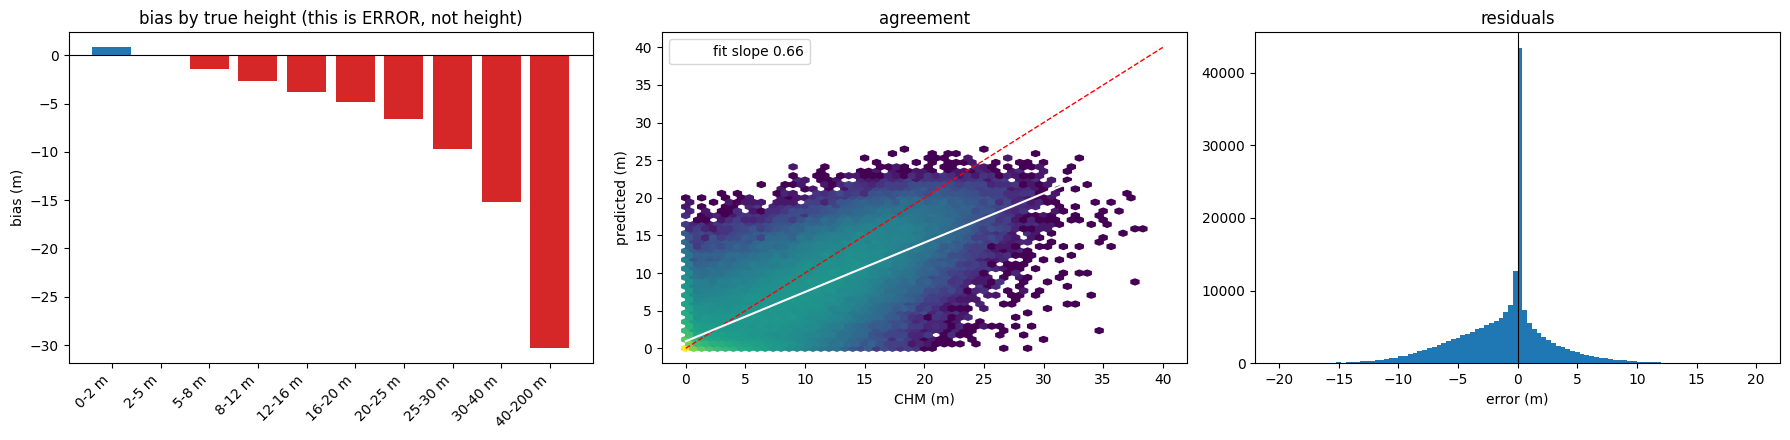

predicted range 0.00-30.29 m  |  reference range 0.00-50.98 m
Predictions are non-negative by construction (softplus head).
Negative values anywhere above are prediction MINUS truth, i.e. error.


In [ ]:
# --- error vs true height, both scopes ---------------------------------------
edges = np.array([0, 2, 5, 8, 12, 16, 20, 25, 30, 40, 200], float)
p, t = PRED[vt], yt[vt]
rows = []
for lo, hi in zip(edges[:-1], edges[1:]):
    m = (t >= lo) & (t < hi)
    if m.sum() < 100: continue
    e = p[m] - t[m]
    rows.append(dict(bin=f"{lo:g}-{hi:g} m", n=int(m.sum()), pct=100*m.mean(),
                     mae=np.abs(e).mean(), bias=e.mean(), pred_mean=p[m].mean()))
bins = pd.DataFrame(rows)
display(bins.round(3))

f, ax = plt.subplots(1, 3, figsize=(18, 4.5))
ax[0].bar(range(len(bins)), bins.bias, color=np.where(bins.bias < 0, "tab:red", "tab:blue"))
ax[0].axhline(0, c="k", lw=.8); ax[0].set_xticks(range(len(bins)))
ax[0].set_xticklabels(bins["bin"], rotation=45, ha="right")
ax[0].set_ylabel("bias (m)")
ax[0].set_title("bias by true height (this is ERROR, not height)")

s_ = np.random.RandomState(0).choice(len(p), min(200_000, len(p)), replace=False)
ax[1].hexbin(t[s_], p[s_], gridsize=60, bins="log", extent=(0, 40, 0, 40), cmap="viridis")
ax[1].plot([0, 40], [0, 40], "r--", lw=1)
sl, ic = calib_slope(PRED, yt, vt)
ax[1].plot([0, 40], [ic, ic+40*sl], "w-", lw=1.5, label=f"fit slope {sl:.2f}")
ax[1].legend(loc="upper left")
ax[1].set_xlabel("CHM (m)"); ax[1].set_ylabel("predicted (m)"); ax[1].set_title("agreement")

ax[2].hist(p[s_]-t[s_], bins=100, range=(-20, 20))
ax[2].axvline(0, c="k", lw=.8); ax[2].set_xlabel("error (m)"); ax[2].set_title("residuals")
plt.tight_layout(); plt.show()

print(f"predicted range {PRED.min():.2f}-{PRED.max():.2f} m  |  "
      f"reference range {np.nanmin(yt[vt]):.2f}-{np.nanmax(yt[vt]):.2f} m")
print("Predictions are non-negative by construction (softplus head).")
print("Negative values anywhere above are prediction MINUS truth, i.e. error.")

## 15. Export

wrote /content/chm_work/chm_pred_test.tif


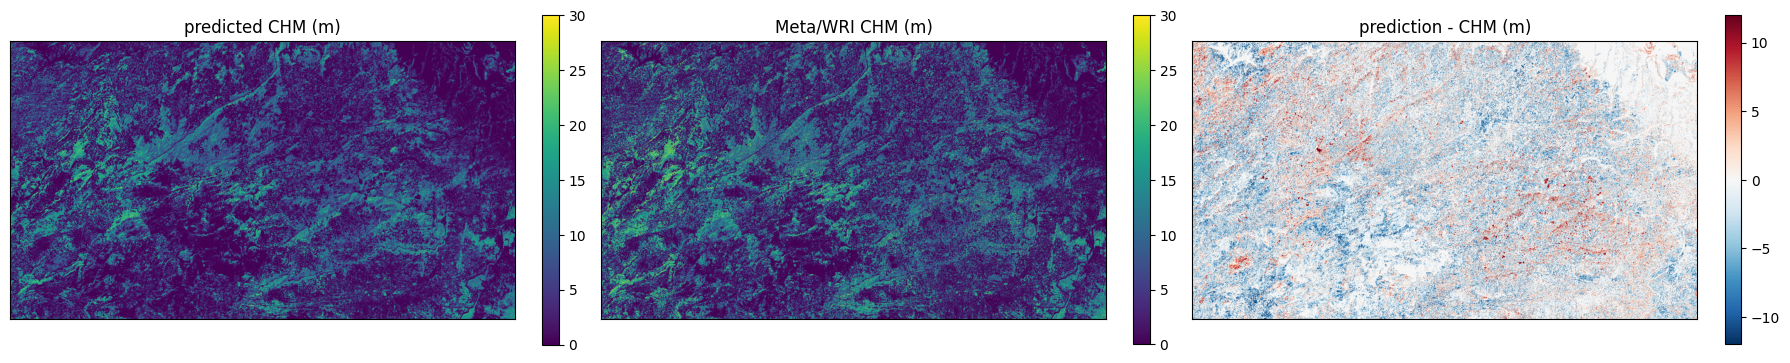

In [ ]:
import rasterio
from rasterio.transform import Affine

meta = META["test"]; C, H, W = meta["shape"]; tr = Affine(*meta["transform"])
out = CFG["WORK"] / "chm_pred_test.tif"
arr = PRED.astype(np.float32).copy()
arr[~np.isfinite(arr)] = -9999.0
with rasterio.open(out, "w", driver="GTiff", height=H, width=W, count=1,
                   dtype="float32", crs=f"EPSG:{meta['epsg']}", transform=tr,
                   nodata=-9999.0, compress="deflate", predictor=3,
                   tiled=True, blockxsize=512, blockysize=512) as d:
    d.write(arr, 1)
    d.update_tags(
        units="metres",
        embeddings="AlphaEarth Foundations (Google / Google DeepMind), CC-BY 4.0",
        aef_years=str(meta["years"]),
        labels="Meta/WRI High Resolution Canopy Height Maps, CC-BY 4.0; "
               "source imagery (c) 2016 Maxar; Tolan et al. 2024 RSE 300:113888",
        chm_prefix=CFG["CHM_PREFIX"], chm_agg=CFG["CHM_AGG"], model="UNet regression")
print("wrote", out)

f, ax = plt.subplots(1, 3, figsize=(18, 5.5))
d = 4
im = ax[0].imshow(PRED[::d, ::d], vmin=0, vmax=30, cmap="viridis")
ax[0].set_title("predicted CHM (m)"); plt.colorbar(im, ax=ax[0], fraction=.03)
ref = yt[::d, ::d].copy(); ref[~vt[::d, ::d]] = np.nan
im = ax[1].imshow(ref, vmin=0, vmax=30, cmap="viridis")
ax[1].set_title("Meta/WRI CHM (m)"); plt.colorbar(im, ax=ax[1], fraction=.03)
dif = PRED[::d, ::d] - ref
im = ax[2].imshow(dif, vmin=-12, vmax=12, cmap="RdBu_r")
ax[2].set_title("prediction - CHM (m)"); plt.colorbar(im, ax=ax[2], fraction=.03)
for a in ax: a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

## 16. Interpreting this

**What the number means.** RMSE here is agreement with the Tolan CHM, which is a ViT prediction
from 2016–2020 Maxar RGB, not a lidar measurement. Tolan et al. report roughly 2.8 m MAE against
airborne lidar in their own validation, and the model saturates in tall canopy. Your error
against it is therefore a floor on error against real canopy height, never a ceiling. Report it
as "agreement with Meta/WRI CHM", not as "canopy height accuracy".

**Read the bias-by-height table before the headline RMSE.** Regression to the mean is the
standard failure mode: near-zero overall bias can hide systematic over-prediction of short
vegetation and under-prediction of tall canopy that cancel in aggregate.

**What this tells you about the bamboo problem.** If cross-region R2 here is good while the
bamboo model struggled on the same embeddings, AOIs, and split, that is real evidence for your
label-mismatch hypothesis rather than against the AEF representation. If CHM *also* transfers
poorly, the shared cause is more likely the ~230 km domain gap, and the bamboo labels are
partly exonerated. Either outcome is informative, which is what makes this a good control.

**Worth trying next:**

1. `YEARS=[2018, 2019]` for 128 channels. CHM source imagery spans years, so a two-year
   embedding may match it better than a single calendar year.
2. `LOG_TARGET=True`. Height is right-skewed with a spike at zero; training on `log1p` spreads
   the short-vegetation range and often improves relative error at the low end.
3. `CHM_PREFIX` -> the v2 DINOv3 product. Different saturation and different imagery; re-run
   section 6 QC before comparing numbers across versions.
4. Fine-tune on a held-out block of the test region and report zero-shot and few-shot separately
   — with a domain gap this large, both numbers are meaningful and they answer different
   questions.
5. If it works well, the trained model is a bamboo-relevant feature source in its own right:
   predicted height and the bamboo labels can be compared directly, which is a sharper test of
   the label mismatch than either model alone.
